# MASTER THESIS - model V3

This notebook demonstrates the usage of the `DarkGreyBox` models via fitting them with `DarkGreyFit`

## Importation

In [1]:
import sys
import importlib
from pathlib import Path

# go from ...\docs\tutorials up two levels to the repo root (...\darkgreybox)
repo_root = Path.cwd().parents[1]
sys.path.insert(0, str(repo_root))
importlib.invalidate_caches()


import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, KFold
from statsmodels.graphics.tsaplots import plot_pacf

from darkgreybox.models import TiThTmTrcn3R3C
from darkgreybox.fit import darkgreyfit
from docs.tutorials.util.plot import plot
from docs.tutorials.util.error import rmse

2026-01-18 21:43:47,972 darkgreybox  INFO     Logging enabled...


Our temporal resolution is 5 minutes

In [2]:
# the duration of a record (in h - 5 minutes)
rec_duration = 5/60

Read some demo data.  
* Ph: Heating system power output
* Ta: Ambient temperature
* Ti: Internal temperature

We are also setting a set of custom fields in our input data: `Ti0`, `Th0` and `Te0`. These fields define the initial conditions for `Ti`, `Th` and `Te` for each record of the input data respectively. E.g. if a sub-model is trained based on the 10-20 records of the training data, the initial conditions for the above params will be set by the 10. record of the input data. 

Note: This demo data is intentionally far from ideal and particularly challenging to model with low errors. It is taken from a building where there are many factors influencing the heat dynamics of the building that are not accounted for in the modelling (solar gains, passive gains, hot water demand, gas use in the canteen etc.). The time period is relatively short to maintain a reasonable solution time for the demo. However, it includes an also challenging holiday period when the heating system is shut down.

In [3]:
input_df = pd.read_csv('./data/general_data_csv_V3_cleaned.csv', index_col=0, parse_dates=True)

input_df['Ti'] = input_df['R01_06_TRU01']
input_df['qv'] = input_df['R01_06_FCI01']
input_df['c'] = input_df['R01_06_CO201']  # Use processed CO2 column
input_df['MVV'] = input_df['R01_06_MVV01']
input_df['Ta'] = input_df['HTR9_VES01_TUD01']
input_df['Ik'] = input_df['HTR9_VES01_SI01']
input_df['Tfor'] = input_df['HTRK_RAD03_TF01']
input_df['Tsup'] = input_df['HTR9_VEN01_TI01']


# Set initial conditions
input_df['Ti0'] = input_df['Ti'].iloc[0]
input_df['Th0'] = input_df['Ti'].iloc[0]*1.05
input_df['Tm0'] = input_df['Ti'].iloc[0]
input_df['Tr0'] = input_df['Tfor'].iloc[0]*0.95
input_df['c0'] = input_df['c'].iloc[0]
input_df['N0'] = 0 #We suppose no one in the room at the beginning
input_df['Phi0'] = 0.5 * (input_df['Th0'] - input_df['Tr0']) / (input_df['Tfor'].iloc[0] - input_df['Tr0']) if (input_df['Tfor'].iloc[0] > input_df['Tr0'].iloc[0]) else 0.1 # Phi0 ≈ (Th0 - Tr0) / (Tfor0 - Tr0)   # From Q = m cp ΔT, m ~ Phi

input_X = input_df[['qv', 'c', 'MVV', 'Ta', 'Ik', 'Tfor', 'Tsup', 'Ti0', 'Th0', 'Tm0', 'Tr0', 'c0', 'N0', 'Phi0']]
input_y = input_df['Ti']


print(f'Input X shape: {input_X.shape}, input y shape: {input_y.shape}')

Input X shape: (34552, 14), input y shape: (34552,)


In [4]:
X_train, X_test, y_train, y_test = train_test_split(input_X, input_y, test_size=0.2, shuffle=False)

print(f'Train: X shape: {X_train.shape}, y shape: {y_train.shape}')
print(f'Test: X shape: {X_test.shape}, y shape: {y_test.shape}')

Train: X shape: (27641, 14), y shape: (27641,)
Test: X shape: (6911, 14), y shape: (6911,)


Set up the model training parameters for each model instance that we want to spin up in the pipeline.  

The `Ti0` param is the initial condition for the internal temperature at t=0 - this is set to the first record of `X_train['Ti0']` as described above and is fixed, hence `vary: False`.  

The `Te0` param is the initial condition for the building envelope temperature at t=0 - - this is set to the first record of `X_train['Te0']` as described above and is NOT fixed, hence `vary: True`.  

The `Th0` param is the initial condition for the heating system temperature at t=0 - - this is set to the first record of `X_train['Th0']` as described above and is NOT fixed, hence `vary: True`.  

`Ci`, `Ce`, `Rie` and `Ria` params are the initial conditions for these thermal parameters. As these will be fit by the model training their default is `vary: True`. The values for these params' initial conditions are set arbitrarily to `1` it is assumed that no estimates have been calculated for them (e.g. based on building physical properties).

Note that we've added the `Ch` and `Rih` params with set initial conditions not allowed to vary. These are the RC params for the heating system and their values have been precalculated from the heating system's time constant to make this example simpler.


In [5]:
S_room = 11             #Surface of the room, found on Revit (m²)
A_windows = 5.48        #Window area found on Revit (m²)
H_room = 2.7            #Height of the room (m)


## Phi_max estimation
Heat_demand = 100       # W/m² (Denmark winter design) (80-120)
cp_w = 4184             # J/kgK
Q_design = S_room * Heat_demand  # W
ΔT_water = 10           #K (supply 50°C → return 40°C typical)
m_max = Q_design / (cp_w * ΔT_water)



train_params_TiThTmTrcn3R3C = {
    'Ti0': {'value': X_train.iloc[0]['Ti0'], 'vary': False},
    'Th0': {'value': X_train.iloc[0]['Th0'], 'vary': True, 'min': 5, 'max': 35},
    'Tm0': {'value': X_train.iloc[0]['Ti0'], 'vary': False},
    'Tr0': {'value': X_train.iloc[0]['Ti0'], 'vary': False},
    'c0': {'value': X_train.iloc[0]['c0'], 'vary': False},
    'N0': {'value': X_train.iloc[0]['N0'], 'vary': False},
    'Phi0': {'value': X_train.iloc[0]['Phi0'], 'vary': False},
    
    'Ci': {'value': 5000, 'vary': True, 'min': 1000, 'max': 50000},
    'Ch': {'value': 250000, 'vary': True, 'min': 100000, 'max': 500000},
    'Cm': {'value': 100000, 'vary': True, 'min': 10000, 'max': 1000000},  # Bigger mass
    'Cf': {'value': 300.0, 'vary': True, 'min': 10, 'max': 1000},       # Valve time constant ~5min
    'Rih': {'value': 0.05, 'vary': True, 'min': 0.001, 'max': 0.5},      # Heater-air
    'Rim': {'value': 0.1, 'vary': True, 'min': 0.01, 'max': 1.0},        # Mass-air  
    'Rfr': {'value': 0.02, 'vary': True, 'min': 0.001, 'max': 0.2},      # Fin-return
    'Rout': {'value': 0.15, 'vary': True, 'min': 0.01, 'max': 2.0},      # Envelope
    'q_pers': {'value': 75, 'vary': False},
    'q_equip_var': {'value': 80, 'vary': False},
    'q_equip_const': {'value': 10, 'vary': False},
    'V': {'value': S_room*H_room, 'vary': False},
    'S': {'value': S_room, 'vary': False},
    'A': {'value': A_windows, 'vary': False},
    'G': {'value': 0.016, 'vary': False},
    'c_out': {'value': 400, 'vary': False},
    'rho_air': {'value': 1.2, 'vary': False},
    'cp_air': {'value': 1000, 'vary': False},
    'Phi_max': {'value': m_max, 'vary': True, 'min': 0.5*m_max, 'max': 1.5*m_max}, # vary between 50% and 150% of estimated max flow rate
    'cp_w': {'value': 4184, 'vary': False},
    'g': {'value': 0.35, 'vary': False},
}

# Verify stability
print(f"dt = {rec_duration:.4f} hours")

dt = 0.0833 hours


Set up our initial conditions parameters map for testing

In [6]:
ic_params_map = {
    'Ti0': lambda _X_test, y_test, _train_result: y_test.iloc[0],
    'Th0': lambda _X_test, _y_test, train_result: train_result.var['Th'][-1],
    'Tm0': lambda X_test, _y_test, train_result: train_result.var['Tm'][-1] if 'Tm' in train_result.var else X_test.iloc[0]['Tm0'],
    'Tr0': lambda X_test, _y_test, train_result: train_result.var['Tr'][-1] if 'Tr' in train_result.var else X_test.iloc[0]['Tr0'],
    'c0': lambda X_test, _y_test, train_result: train_result.var['c'][-1] if 'c' in train_result.var else X_test.iloc[0]['c0'],
    'N0': lambda X_test, _y_test, train_result: train_result.var['N'][-1] if 'N' in train_result.var else X_test.iloc[0]['N0'],
    'Phi0': lambda X_test, _y_test, _train_result: X_test.iloc[0]['Phi0']
}

We need to split our training data set into managable chunks for the prefit stage. `Sklearn` is quite helpful here again, in case we wanted to define the prefit sets to be 1 day (24 hours) long:

In [7]:
prefit_splits = KFold(n_splits=int(len(X_train) / 24), shuffle=False).split(X_train)

To evaluate the performance of our models we will need to define an error metric. Again, there is a wide range of options available from `sklearn`:

In [8]:
error_metric = rmse

We can define a prefit "survival threshold" to trim the number of model fits during the training process. Any models achieving a higher error during the prefit stage will not make it into the training stage.

In [9]:
prefit_filter = lambda error: abs(error) < 2

Under the hood, `DarkGreyBox` uses `lmfit.minimize` to fit the thermal model parameters to the training data by passing it a custom objective function defined by the model class. The fit method used by `lmfit.minimize` can be customised as well, and while the standard Nelder-Mead and Levenberg-Marquardt methods work well in general, it is worth experimenting with others (see here for a list of supported methods: https://lmfit.github.io/lmfit-py/fitting.html#fit-methods-table).

In [10]:
method = 'nelder'

Setting up is ready! We only need to call the `darkgreyfit` convenience pipeline function that delegates the work to the prefit, train and test low-level procedures running on multiple processes and reducing / cleaning the interim results. The returned `pandas.DataFrame` contains the fit models and their train/test performance evaluation.   


In [11]:
models = [TiThTmTrcn3R3C(train_params_TiThTmTrcn3R3C, rec_duration)]

In [ ]:
# Reload modules to get the max_nfev limit
importlib.reload(sys.modules['darkgreybox.base_model'])
importlib.reload(sys.modules['darkgreybox.models'])
from darkgreybox.models import TiThTmTrcn3R3C

# Subsample to reduce data size
subsample_factor = 12  # 12 = hourly, 1 = full 5-min data

X_train_sub = X_train.iloc[::subsample_factor].copy()
y_train_sub = y_train.iloc[::subsample_factor].copy()
X_test_sub = X_test.iloc[::subsample_factor].copy()
y_test_sub = y_test.iloc[::subsample_factor].copy()

rec_duration_sub = rec_duration * subsample_factor
models_sub = [TiThTmTrcn3R3C(train_params_TiThTmTrcn3R3C, rec_duration_sub)]

print(f"Train size: {len(X_train_sub)} samples (subsampled by {subsample_factor}x)")
print(f"dt: {rec_duration_sub:.4f}h")
print(f"Max function evaluations: 1000 (added limit to prevent endless runs)")

# Run with subsampled data
df = darkgreyfit(
    models=models_sub,
    X_train=X_train_sub,
    y_train=y_train_sub,
    X_test=X_test_sub,
    y_test=y_test_sub,
    ic_params_map=ic_params_map,
    error_metric=error_metric,
    prefit_filter=None,
    prefit_splits=None,
    method='leastsq',
    n_jobs=1
)

print("Fitting complete!")
print(f"DataFrame shape: {df.shape}")

Data size: 2304 samples
One model evaluation: 0.0337 seconds
Optimizer calls ~500-2000 evaluations → 16.8 to 67.4 seconds total
Result Ti shape: (2304,), first values: [24.6        24.61057365 24.62014031 24.62891582 24.63791398]


In this specific example:
* *Initial Population:* 5 model structures were prefit to 28x 24-hour data chunks resulting in 140 pipelines
* *Fitness Function:* The RMSE of a prefit had to be < 2˚C to survive
* *Selection:* 110 pipelines survived the prefit selection and made it into training on the entire training set 
* (No *Crossover* or *Mutation*)
* *Termination:* Out of the 110 pipelines trained, 11 distinct model results were found (i.e. many pipelines were arriving at the same parameter set results)

In [13]:
df

train                            \
                 start_date                  end_date   
0 2025-04-30 22:00:00+00:00 2025-08-22 21:55:00+00:00   

                                                      \
                                               model   
0  <darkgreybox.models.TiTmxvCN2R2C object at 0x0...   

                                                                          \
                                        model_result        time  method   
0  DarkGreyModelResult(Z=array([24.6       , 24.5...  191.367497  nelder   

                                 test                            \
      error                start_date                  end_date   
0  0.653971 2025-08-22 22:00:00+00:00 2025-09-15 21:55:00+00:00   

                                                      \
                                               model   
0  <darkgreybox.models.TiTmxvCN2R2C object at 0x0...   

                                                                          
                                        model_result      time     error  
0  DarkGreyModelResult(Z=array([24.9       , 24.8...  0.051963  0.526333

We can select the model with the lowest error and display its params

In [28]:
select_idx = df[('train', 'error')].argmin()

model = df.loc[select_idx, ('train', 'model')]
train_results = df.loc[select_idx, ('train', 'model_result')]
test_results = df.loc[select_idx, ('test', 'model_result')]

model.result.params

name,value,initial value,min,max,vary
Ti0,24.9000000,24.6,-inf,inf,False
Th0,24.7684431,24.6,5.00000000,35.0000000,True
xv0,0.00000000,0.0,-inf,inf,False
C0,417.000000,423.7321429,-inf,inf,False
N0,0.00000000,0.0,-inf,inf,False
Ci,7804.59874,5000.0,1000.00000,50000.0000,True
Ch,500000.000,250000.0,100000.000,500000.000,True
Rint,0.00249986,0.05,1.0000e-03,1.00000000,True
Rout,0.01034333,0.1,1.0000e-03,2.00000000,True
alpha,75.0000000,75.0,-inf,inf,False


The results show that the `TiTeThRia` model has a good fit on the training set (R2=0.9612) and the errors are low for both the training and test sets (RMSE 0.3719 and 0.3383 respectively) indicating that the model generalises well for data it hasn't seen before (no overfitting problem).

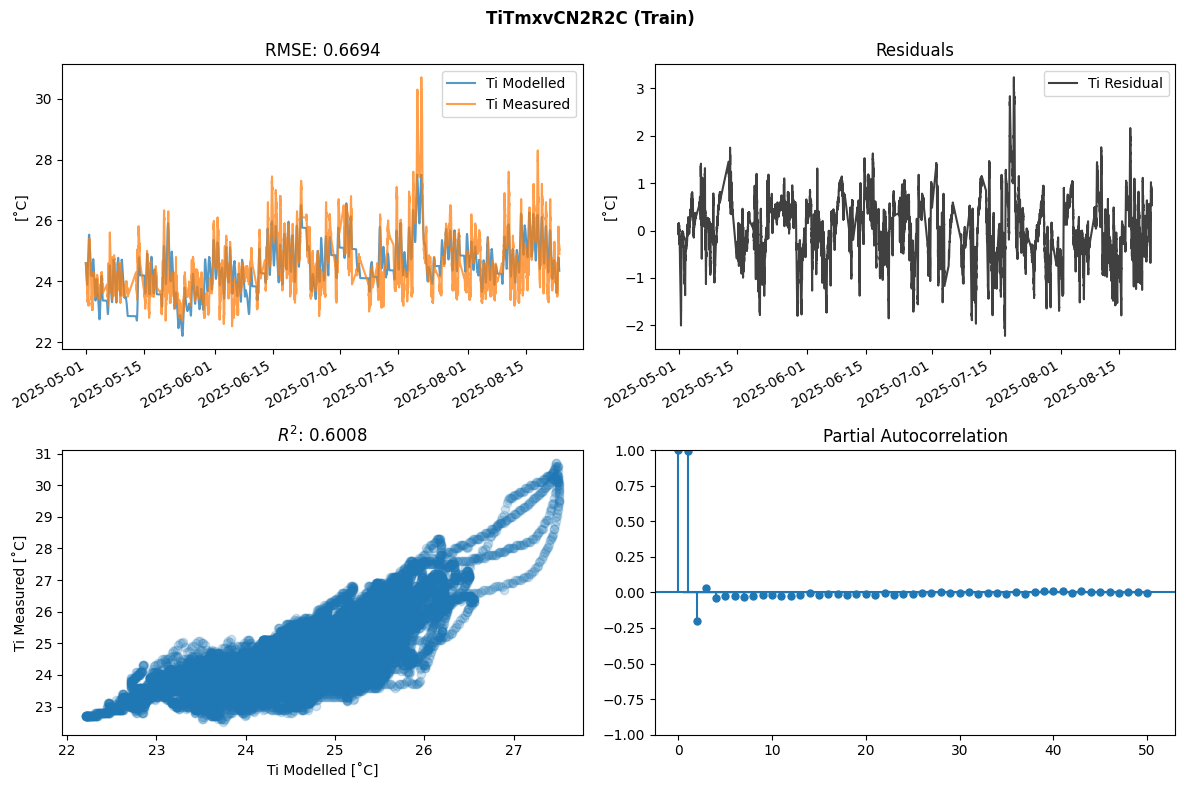

In [31]:
plot(y_train, train_results, 'TiTmxvCN2R2C (Train)')

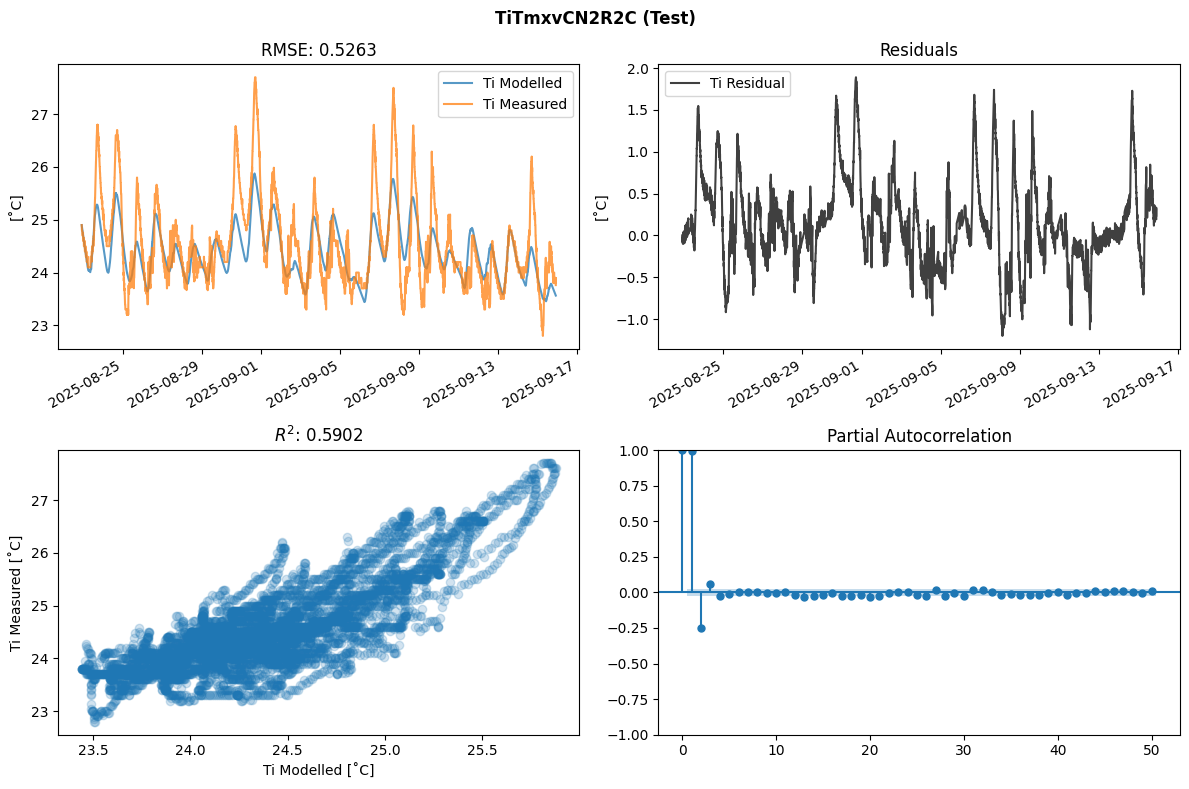

In [17]:
plot(y_test, test_results, 'TiTmxvCN2R2C (Test)')

In contrast, the `Ti` model has a poor fit on the training set (R2=0.79) which is clear from the temperature plots as well. Due to low model complexity there is a definite underfitting problem going in here, which of course also results in poor test set performance. This is hardly surprising, as the `Ti` model only keeps internal states of the internal temperatures (`Ti`) and it is unaware of the internal states of the heating system / building envelope temperatures  (`Th` and `Te` respectively) - both of which are important for describing the system components' thermal inertia.

## Using the Kalman Filter Model for Occupancy Estimation

The `TiTmxvCN2R2C_KF` model extends the base model with a Kalman filter that updates the occupancy estimate N at each timestep based on CO2 observations. This allows N to vary over time instead of staying constant.

In [29]:
# Reload the models module to get the new TiTmxvCN2R2C_KF class
importlib.reload(sys.modules['darkgreybox.models'])
from darkgreybox.models import TiTmxvCN2R2C_KF

# Add the CO2 observations to the input data for the Kalman filter
input_df['C_obs'] = input_df['C']  # Use measured CO2 as observations
input_df['P_N0'] = 1.0  # Initial variance of N estimate (constant for all rows)

# Update input_X to include C_obs and P_N0
input_X_kf = input_df[['Ta', 'Tfor', 'Q_vent', 'Q_solar', 'MVV', 'ACH', 'Ti0', 'Th0', 'xv0', 'C0', 'N0', 'C_obs', 'P_N0']]

# Split for KF model
X_train_kf, X_test_kf, _, _ = train_test_split(input_X_kf, input_y, test_size=0.2, shuffle=False)

# Add Kalman filter parameters to the training params
train_params_KF = train_params_TiTmxvCN2R2C.copy()
train_params_KF['Q_N'] = {'value': 0.5, 'vary': False}     # Process noise for N (persons²/h)
train_params_KF['R_C'] = {'value': 50.0, 'vary': False}    # Measurement noise for CO2 (ppm²)
train_params_KF['P_N0'] = {'value': 1.0, 'vary': False}    # Initial variance of N

print("Training parameters for Kalman Filter model:")
print(f"  Q_N (process noise): {train_params_KF['Q_N']['value']}")
print(f"  R_C (measurement noise): {train_params_KF['R_C']['value']}")

Training parameters for Kalman Filter model:
  Q_N (process noise): 0.5
  R_C (measurement noise): 50.0


In [30]:
# Create and fit the Kalman Filter model
models_kf = [TiTmxvCN2R2C_KF(train_params_KF, rec_duration)]

# Update ic_params_map for KF model
ic_params_map_kf = {
    'Ti0': lambda X_test, y_test, train_result: y_test.iloc[0],
    'Th0': lambda X_test, y_test, train_result: train_result.var['Th'][-1],
    'xv0': lambda X_test, y_test, train_result: X_test.iloc[0]['xv0'],
    'C0': lambda X_test, y_test, train_result: X_test.iloc[0]['C0'],
    'N0': lambda X_test, y_test, train_result: train_result.var['N'][-1],  # Use last estimated N
    'P_N0': lambda X_test, y_test, train_result: train_result.var['P_N'][-1],  # Use last variance
}

df_kf = darkgreyfit(
    models=models_kf,
    X_train=X_train_kf,
    y_train=y_train,
    X_test=X_test_kf,
    y_test=y_test,
    ic_params_map=ic_params_map_kf,
    error_metric=error_metric,
    prefit_filter=None,
    prefit_splits=None,
    n_jobs=1
)

print("Kalman Filter model training complete!")

2026-01-18 16:28:37,879 darkgreybox  INFO     Training models...
2026-01-18 16:31:30,650 darkgreybox  INFO     Generating predictions for 1 models...
Kalman Filter model training complete!


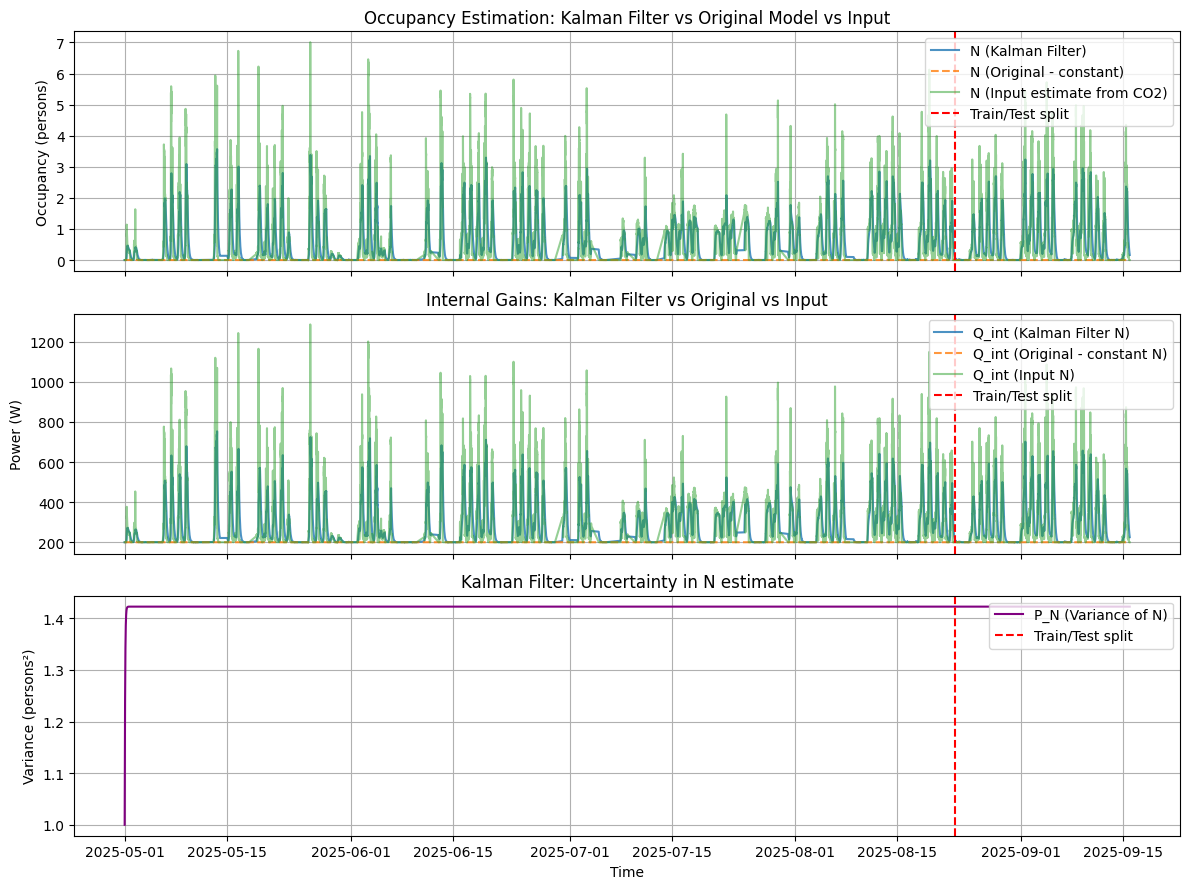


--- Model Comparison ---
Original Model - Train RMSE: 0.6694°C
Original Model - Test RMSE:  0.5648°C
Kalman Filter  - Train RMSE: 0.7193°C
Kalman Filter  - Test RMSE:  0.6548°C


In [32]:
# Extract results from Kalman Filter model
select_idx_kf = df_kf[('train', 'error')].argmin()
model_kf = df_kf.loc[select_idx_kf, ('train', 'model')]
train_results_kf = df_kf.loc[select_idx_kf, ('train', 'model_result')]
test_results_kf = df_kf.loc[select_idx_kf, ('test', 'model_result')]

# Extract N from original model (non-KF)
N_train = train_results.var['N']
N_test = test_results.var['N']

# Compare N from original model vs Kalman Filter model
N_kf_train = train_results_kf.var['N']
N_kf_test = test_results_kf.var['N']
N_kf_full = np.concatenate([N_kf_train, N_kf_test])

# Get parameters for Q_int calculation
q_pers = train_params_TiTmxvCN2R2C['q_pers']['value']
q_equip_var = train_params_TiTmxvCN2R2C['q_equip_var']['value']
Q_int_const = train_params_TiTmxvCN2R2C['Q_int_const']['value']

# Plot comparison of N estimates
fig, axes = plt.subplots(3, 1, figsize=(12, 9), sharex=True)

idx = input_y.index

# Plot 1: N comparison
axes[0].plot(idx, N_kf_full, label='N (Kalman Filter)', alpha=0.8)
axes[0].plot(idx, np.concatenate([N_train, N_test]), label='N (Original - constant)', linestyle='--', alpha=0.8)
axes[0].plot(input_df.loc[idx, 'N'], label='N (Input estimate from CO2)', alpha=0.5)
axes[0].axvline(x=y_train.index[-1], color='r', linestyle='--', label='Train/Test split')
axes[0].set_ylabel('Occupancy (persons)')
axes[0].set_title('Occupancy Estimation: Kalman Filter vs Original Model vs Input')
axes[0].legend(loc='upper right')
axes[0].grid(True)

# Plot 2: Q_int comparison
Q_int_kf = Q_int_const + (q_pers + q_equip_var) * N_kf_full
Q_int_orig = Q_int_const + (q_pers + q_equip_var) * np.concatenate([N_train, N_test])
Q_int_input = Q_int_const + (q_pers + q_equip_var) * input_df.loc[idx, 'N'].values
axes[1].plot(idx, Q_int_kf, label='Q_int (Kalman Filter N)', alpha=0.8)
axes[1].plot(idx, Q_int_orig, label='Q_int (Original - constant N)', linestyle='--', alpha=0.8)
axes[1].plot(idx, Q_int_input, label='Q_int (Input N)', alpha=0.5)
axes[1].axvline(x=y_train.index[-1], color='r', linestyle='--', label='Train/Test split')
axes[1].set_ylabel('Power (W)')
axes[1].set_title('Internal Gains: Kalman Filter vs Original vs Input')
axes[1].legend(loc='upper right')
axes[1].grid(True)

# Plot 3: Variance of N (uncertainty)
P_N_train = train_results_kf.var['P_N']
P_N_test = test_results_kf.var['P_N']
P_N_full = np.concatenate([P_N_train, P_N_test])
axes[2].plot(idx, P_N_full, label='P_N (Variance of N)', color='purple')
axes[2].axvline(x=y_train.index[-1], color='r', linestyle='--', label='Train/Test split')
axes[2].set_ylabel('Variance (persons²)')
axes[2].set_xlabel('Time')
axes[2].set_title('Kalman Filter: Uncertainty in N estimate')
axes[2].legend(loc='upper right')
axes[2].grid(True)

plt.tight_layout()
plt.show()

# Print RMSE comparison
print(f"\n--- Model Comparison ---")
print(f"Original Model - Train RMSE: {df.loc[select_idx, ('train', 'error')]:.4f}°C")
print(f"Original Model - Test RMSE:  {df.loc[select_idx, ('test', 'error')]:.4f}°C")
print(f"Kalman Filter  - Train RMSE: {df_kf.loc[select_idx_kf, ('train', 'error')]:.4f}°C")
print(f"Kalman Filter  - Test RMSE:  {df_kf.loc[select_idx_kf, ('test', 'error')]:.4f}°C")

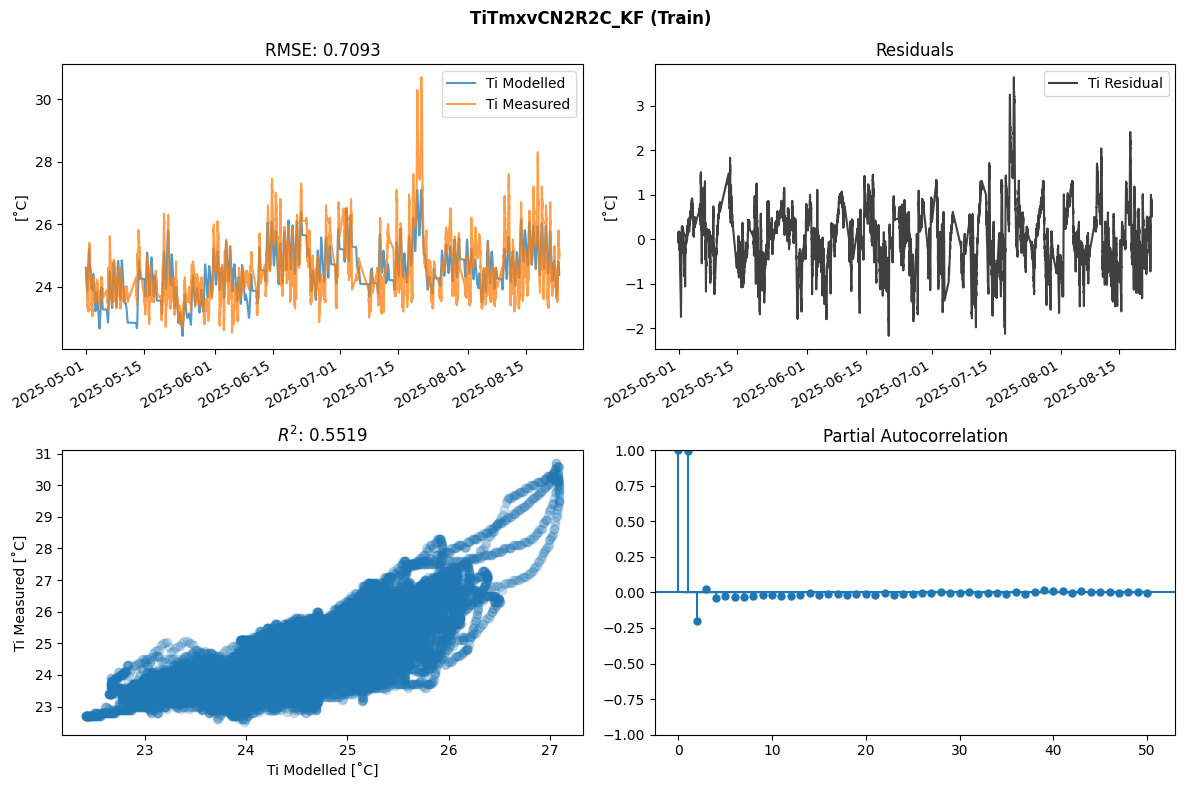

In [21]:
# Plot Train results for Kalman Filter model
plot(y_train, train_results_kf, 'TiTmxvCN2R2C_KF (Train)')

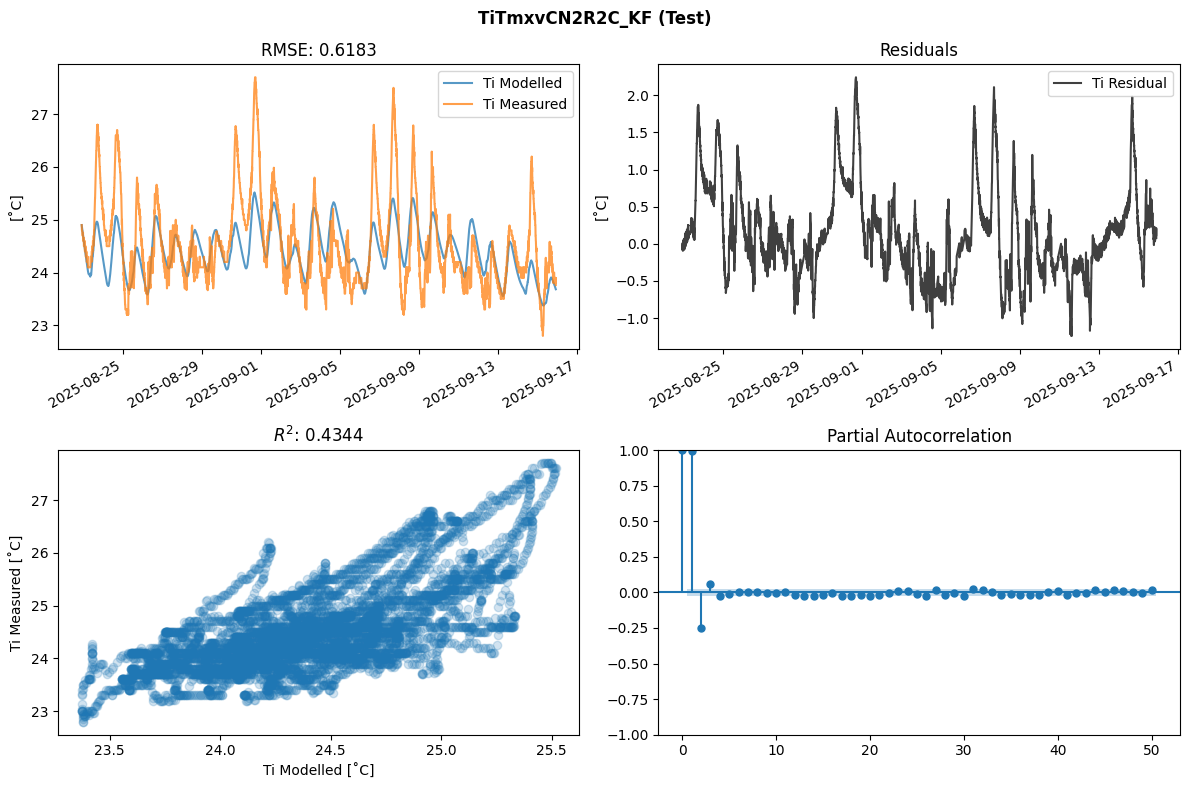

In [22]:
# Plot Test results for Kalman Filter model
plot(y_test, test_results_kf, 'TiTmxvCN2R2C_KF (Test)')